# Exercice 4

**Données :** `FTML/project/data/regression/` (`X_train`, `y_train`, `X_test`, `y_test`).

**Objectif :** obtenir un score $R^2 > 0.88$ sur le **jeu de test**, qui ne doit
jamais servir pendant *l'entraînement* (entraînement = toute la procédure :
choix du modèle + réglage des hyperparamètres, pas seulement l'appel à `.fit()`).
L'estimateur de Bayes atteint $R^2 \approx 0.92$.

On compare (au moins) deux méthodes :

| Méthode | Régularisation | Idée |
|---|---|---|
| **OLS** (`LinearRegression`) | aucune | référence non régularisée |
| **Ridge** (`RidgeCV`) | $\ell_2$ | rétrécit tous les coefficients |
| **Lasso** (`LassoCV`) | $\ell_1$ | met des coefficients **exactement** à 0 (parcimonie) |


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


def find_data(sub: str) -> Path:
    """Finds the requested resource in the FTML/project/data folder.

    Different levels of path are tested to account for nested setups.

    Parameters
    ----------
    sub : str
        Resource to get.

    Returns
    -------
    Path
        The path to the requested resource.

    Raises
    ------
    FileNotFoundError
        The resource wasn't found.
    """
    for base in [
        Path("../FTML/project/data"),
        Path("FTML/project/data"),
        Path("../../FTML/project/data"),
    ]:
        if (base / sub).exists():
            return base / sub
    raise FileNotFoundError(sub)


REG = find_data("regression")
X_train = np.load(REG / "X_train.npy")
y_train = np.load(REG / "y_train.npy").ravel()
X_test = np.load(REG / "X_test.npy")
y_test = np.load(REG / "y_test.npy").ravel()

print("X_train :", X_train.shape, "| X_test :", X_test.shape)
print(
    "y_train :",
    y_train.shape,
    "| y mean/std :",
    round(y_train.mean(), 3),
    "/",
    round(y_train.std(), 3),
)
print("n_features (d) =", X_train.shape[1], " ; n_train =", X_train.shape[0])

# Condition number diagnostic (n = d case)
s = np.linalg.svd(X_train, compute_uv=False)
kappa = s.max() / s.min()
print(
    f"\nrang(X_train) = {np.linalg.matrix_rank(X_train)} / {X_train.shape[1]}  "
    f"(invertible square matrix)"
)
print(f"sigma_max = {s.max():.2f} ; sigma_min = {s.min():.4f}")
print(f"Condition number kappa = sigma_max / sigma_min = {kappa:.0f}")


X_train : (200, 200) | X_test : (200, 200)
y_train : (200,) | y mean/std : 4.907 / 0.945
n_features (d) = 200  ; n_train = 200

rang(X_train) = 200 / 200  (invertible square matrix)
sigma_max = 99.86 ; sigma_min = 0.0188
Condition number kappa = sigma_max / sigma_min = 5308


## 1. Analyse et méthodologie

On a $n = 200$ observations pour $d = 200$ variables : **$n = d$**, régime de
**grande dimension**.

**Carrée ≠ inversible ≠ bien conditionnée.** La cellule ci-dessus montre que
$X_{\text{train}}$ est carrée *et* de rang plein ($200/200$) : elle est donc
**inversible**. Le
*conditionnement* est mesuré par
$$\kappa = \frac{\sigma_{\max}}{\sigma_{\min}},$$
rapport entre la plus grande et la plus petite valeur singulière. Ici
$\kappa \approx 5300$ : la matrice est inversible mais **très mal conditionnée**.


**Conséquence sur OLS.** La solution $\hat\beta = (X^\top X)^{-1}X^\top y$ divise,
dans la base des vecteurs singuliers, chaque composante par $\sigma_i^2$ : le
long des directions « molles » ($\sigma_i\approx 0.02$) le bruit de $y$ est
amplifié. De plus, avec $200$ paramètres pour $200$
équations, OLS **interpole** le train (résidu nul, zéro degré de liberté
restant) et mémorise le bruit → variance énorme, $R^2$ test **négatif**. Il faut
**régulariser** : Ridge remplace $\sigma_i^2$ par $\sigma_i^2 + \alpha$, ce qui
borne l'amplification ; le Lasso annule en plus les variables inutiles.

**Protocole train / validation / test.** Le jeu de test est mis de côté et
n'est touché qu'à la toute fin. Tout le réglage (choix de la méthode, valeur de
$\alpha$) se fait par **validation croisée à 5 plis** *sur le train uniquement* :
chaque hyperparamètre est évalué sur des plis de validation jamais vus par le
`.fit()` correspondant. On ne garde au final qu'**un** modèle, ré-entraîné sur
tout le train, puis évalué une seule fois sur le test.

**Choix du score.** On optimise directement le $R^2$.


In [4]:
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import r2_score

cv = KFold(n_splits=5, shuffle=True, random_state=0)
alphas = np.logspace(-3, 4, 100)

# We normalize the input with L1 and L2 penalties being correct only if all
# variables are of the same scale.
models = {
    "OLS   (no penalty)": make_pipeline(StandardScaler(), LinearRegression()),
    "Ridge (L2, RidgeCV)": make_pipeline(
        StandardScaler(), RidgeCV(alphas=alphas)
    ),
    "Lasso (L1, LassoCV)": make_pipeline(
        StandardScaler(),
        LassoCV(alphas=alphas, cv=cv, max_iter=200000, random_state=0),
    ),
}

print(f"{'Model':<22}{'R2 (CV 5 splits)':>16}{'R2 test':>12}")
print("-" * 50)
results_reg = {}
for name, m in models.items():
    cv_r2 = cross_val_score(m, X_train, y_train, cv=cv, scoring="r2").mean()
    m.fit(X_train, y_train)
    test_r2 = r2_score(y_test, m.predict(X_test))
    results_reg[name] = (cv_r2, test_r2, m)
    print(f"{name:<22}{cv_r2:>16.4f}{test_r2:>12.4f}")


Model                 R2 (CV 5 splits)     R2 test
--------------------------------------------------
OLS   (no penalty)              0.5086     -9.9240
Ridge (L2, RidgeCV)             0.6013      0.7106
Lasso (L1, LassoCV)             0.9346      0.9225


## 2. Discussion : solveurs, optimisation, hyperparamètres

**OLS** s'effondre ($R^2$ test fortement **négatif**) : sans contrainte, en
régime $n=d$, il interpole le train. Son **risque empirique** (erreur sur les
données d'entraînement) est donc quasi nul, mais son **risque réel** (erreur
attendue sur de nouvelles données, estimé ici par le test) explose. C'est
exactement l'écart de généralisation, signature du sur-apprentissage en grande
dimension : minimiser le risque empirique sans contrainte ne garantit pas un petit
risque réel.

**Ridge ($\ell_2$).** Problème lisse et fortement convexe, avec une solution
explicite $\hat\beta = (X^\top X + \alpha I)^{-1} X^\top y$. `RidgeCV` choisit
$\alpha$ par validation croisée. Ridge stabilise mais **garde les 200 variables** :
il ne peut pas exploiter la parcimonie du vrai modèle.

**Lasso ($\ell_1$).** Objectif convexe mais non lisse → pas de solution explicite ;
scikit l'optimise par **descente de coordonnées** (`LassoCV`). La pénalité $\ell_1$
produit une solution **parcimonieuse** : beaucoup de coefficients sont *exactement*
nuls. Le seul hyperparamètre, $\alpha$ (force de pénalité), est choisi par CV.

Le **Lasso domine** : le signal est porté par un petit sous-ensemble de variables,
ce qui correspond exactement à ce que favorise la pénalité $\ell_1$.

CV's selected akpha : 0.01592
Active variables        : 50 / 200 (others are exactly 0)
R2 test (Lasso)          : 0.9225


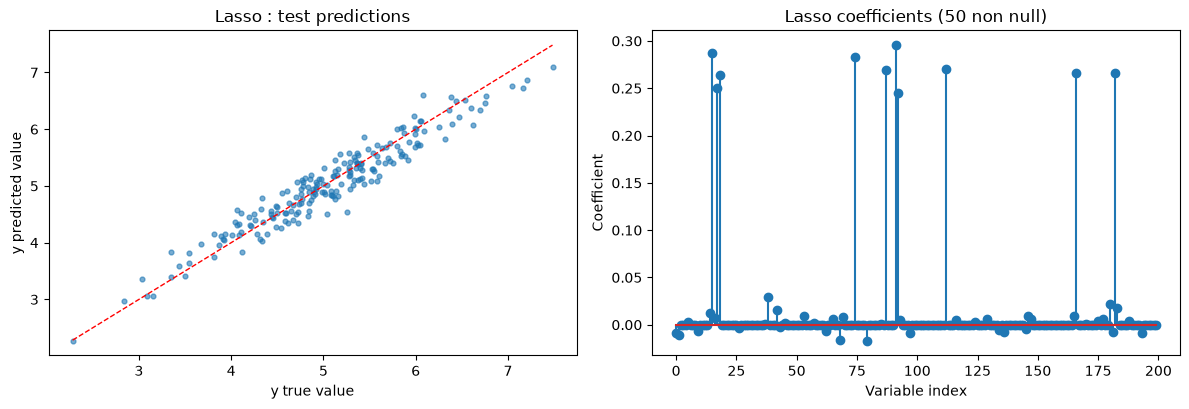

In [6]:
best = results_reg["Lasso (L1, LassoCV)"][2]
lasso = best[-1]
coef = lasso.coef_
print(f"CV's selected akpha : {lasso.alpha_:.5f}")
print(
    f"Active variables        : {(coef != 0).sum()} / {coef.size} "
    f"(others are exactly 0)"
)
print(
    f"R2 test (Lasso)          : {r2_score(y_test, best.predict(X_test)):.4f}"
)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].scatter(y_test, best.predict(X_test), s=12, alpha=0.6)
lims = [y_test.min(), y_test.max()]
ax[0].plot(lims, lims, "r--", lw=1)
ax[0].set_xlabel("y true value")
ax[0].set_ylabel("y predicted value")
ax[0].set_title("Lasso : test predictions")
ax[1].stem(coef)
ax[1].set_xlabel("Variable index")
ax[1].set_ylabel("Coefficient")
ax[1].set_title(f"Lasso coefficients ({(coef != 0).sum()} non null)")
plt.tight_layout()
plt.show()


## 3. Conclusion — Régression

| Modèle | $R^2$ test |
|---|---|
| OLS | $\ll 0$ (sur-apprentissage) |
| Ridge | $\approx 0.71$ |
| **Lasso** | $\approx 0.92$ |

Le **Lasso** atteint $R^2 \approx 0.92$ sur le test, **au-dessus de l'objectif
$0.88$** et au niveau de l'estimateur de Bayes. La clé : en grande dimension
($n=d$) avec un vrai modèle **parcimonieux**, la régularisation $\ell_1$ est le
bon choix — elle sélectionne les variables pertinentes et annule le reste, là où
Ridge se contente de rétrécir et où OLS explose. 
